ISMB 2024 Tutorial: Multi-omic data integration for microbiome research using scikit-bio

# Section 03: Working with various omic data types

We aim to explore ITS fro, EMP biom files; for that goal; here qre the ids of the bio, files; already in the shared drive

These contain ITS in the sequencing technology:
104012
104405
104910
104922
104929
133034
133098
134363
134413
134461

Goals
   - [x] Graph percentage of samples with yeast (ITS)
   - [ ] Search a visualization from shotgun
   - [ ] Explore merged shotgun biom and add metadata
   - [ ] cross by sample ID
   - [ ] Search a visualization from shotgun

## Preparation

Install the latest version of scikit-bio if it hasn't been (needed for every Google Colab instance).

In [1]:
from importlib.util import find_spec

In [2]:
if find_spec('skbio') is None:
    !pip install -q scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 29.7 MB/s eta 0:00:00


In [3]:
import skbio
skbio.__version__

'0.7.0'

Import common libraries.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

If you use Google Colab, and would like to directly mount the shared Google Drive folder containing data files, please uncomment and execute the following code.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# # Specify your remote directory
HOME = '/content/drive/MyDrive/sci-kit-bio_local/Data/emp500'

If you use Google Colab or local Jupyter, and would like to download the data file package to the current directory, please uncomment and execute the following code.

If you use local Jupyter, and have already downloaded and extracted the data file package, please specify its directory.

In [7]:
# # Specify your local directory
#HOME = '/home/drz/Desktop/Data/emp500'

Check if the directory exists by listing its content.

In [8]:
!ls $HOME

amplicon  assembly  masspec  README.md	sample.tsv  shotgun


## The EMP500 study

A `README.md` file within the data directory provides basic information about the study. Take a quick look at it:

## Sample metadata

### Metadata table

The sample metadata table, `sample.tsv`, is a tab-separated values ([TSV](https://en.wikipedia.org/wiki/Tab-separated_values)) file with samples as rows and properties as columns. Let's take a peek at the table:

In [9]:
!head $HOME/sample.tsv | cut -c1-100

sample_name	sample_name_original	sample_type	collection_timestamp	country	depth_sample	description	e
13114.angenent.65.s001	Angenent65.misc.104	bioreactor sludge	08/09/2011 0:00	USA - New York	not appl
13114.angenent.65.s002	Angenent65.misc.519	bioreactor sludge	9/27/12 0:00	USA - New York	not applica
13114.angenent.65.s003	Angenent65.misc.946	bioreactor sludge	11/28/13 0:00	USA - New York	not applic
13114.angenent.65.s004	Angenent65.misc.1022	bioreactor sludge	02/12/2014 0:00	USA - New York	not app
13114.angenent.65.s005	Angenent65.misc.1538	bioreactor sludge	7/13/15 0:00	USA - New York	not applic
13114.angenent.65.s006	Angenent65.misc.1622	bioreactor sludge	10/05/2015 0:00	USA - New York	not app
13114.angenent.65.s007	Angenent65.misc.1722	bioreactor sludge	1/13/15 0:00	USA - New York	not applic
13114.angenent.65.s008	Angenent65.misc.1818	bioreactor sludge	4/18/16 0:00	USA - New York	not applic
13114.angenent.65.s009	Angenent65.misc.1888	bioreactor sludge	6/27/16 0:00	USA - New York	n

In [10]:
from skbio.metadata import SampleMetadata
meta = SampleMetadata.load(f'{HOME}/sample.tsv', default_missing_scheme='INSDC:missing')
#meta
df_meta = meta.to_dataframe()
df_meta.head(3)

,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.angenent.65.s001,Angenent65.misc.104,bioreactor sludge,08/09/2011 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s002,Angenent65.misc.519,bioreactor sludge,9/27/12 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s003,Angenent65.misc.946,bioreactor sludge,11/28/13 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome


In [11]:
# Get the shape of df_meta
df_meta_shape = df_meta.shape

# Print the shape
print(f"The shape of df_meta is: {df_meta_shape}")

The shape of df_meta is: (880, 33)


So there are metadata for 880 samples. In the next section we will filter to keep metadata only of those samples that have a minimal number of reads after quality control.

Here we can test metadata for selected samples.

In [12]:
# Select the row for the specific sample and the 'empo' columns
empo_data_for_sample = df_meta.loc['13114.angenent.65.s001', ['empo_1', 'empo_2', 'empo_3']]

# Display the selected data
print("EMPO categories for sample 13114.zaneveld.9.s021:")
display(empo_data_for_sample)

EMPO categories for sample 13114.zaneveld.9.s021:


,13114.angenent.65.s001
empo_1,Host-associated
empo_2,Animal
empo_3,Animal proximal gut


In [13]:
# Crear un nuevo dataframe con valores únicos de empo_3 y sus jerarquías asociadas
df_hierarchy = (
    df_meta[['empo_1', 'empo_2', 'empo_3']]
    .drop_duplicates(subset=['empo_3'])   # evitar duplicados
    .set_index('empo_3')                  # hacer empo_3 el índice
)

print(df_hierarchy)

                                  empo_1      empo_2
empo_3                                              
Animal proximal gut      Host-associated      Animal
Sediment (non-saline)        Free-living  Non-saline
Plant surface            Host-associated       Plant
Sediment (saline)            Free-living      Saline
Soil (non-saline)            Free-living  Non-saline
Animal corpus            Host-associated      Animal
Surface (saline)             Free-living      Saline
Animal distal gut        Host-associated      Animal
Subsurface (non-saline)      Free-living  Non-saline
Water (non-saline)           Free-living  Non-saline
Water (saline)               Free-living      Saline
Plant corpus             Host-associated       Plant
Fungus corpus            Host-associated      Fungus
Animal secretion         Host-associated      Animal


## Shotgun presence absence kraken analysis

In [14]:
# GitHub raw file URL
github_tsv_url = 'https://raw.githubusercontent.com/nselem/2025LitiVisit/refs/heads/main/code/kraken_absolute_isyeast.tsv'

# Load the TSV file into a pandas DataFrame
try:
    yeast_abundance_df = pd.read_csv(github_tsv_url, sep='\t')

    # Display the head of the DataFrame to verify
    display(yeast_abundance_df.head())

except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure the GitHub link is correct and the file is accessible.")

print(f"Shape of theyeast_abundance_df: {yeast_abundance_df.shape}")

,taxid,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s003,13114.angenent.65.s004,13114.angenent.65.s005,13114.angenent.65.s006,13114.angenent.65.s007,13114.angenent.65.s008,13114.angenent.65.s009,...,phylum,class,order,family,genus,species,subphylum,taxa,result,isyeast
0,2036908,8922.0,0.0,0.0,0.0,0.0,0.0,101.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,jacksonii,Pezizomycotina,Clarireedia,No results found,N
1,2860823,4241.0,0.0,0.0,0.0,231.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,paspali,Pezizomycotina,Clarireedia,No results found,N
2,2867042,3223.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,hainanense,Pezizomycotina,Clarireedia,No results found,N
3,2211668,473.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,monteithiana,Pezizomycotina,Clarireedia,No results found,N
4,2086344,9845.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Erysiphales,Erysiphaceae,Podosphaera,cerasi,Pezizomycotina,Podosphaera,No results found,N


Shape of theyeast_abundance_df: (783, 762)


### Yeast Presence absence graph

This tsv already in github is the result of kraken-bracken analysis (alberto), plus test if every taxon isyeast or no (Elaine script)

,taxid,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s003,13114.angenent.65.s004,13114.angenent.65.s005,13114.angenent.65.s006,13114.angenent.65.s007,13114.angenent.65.s008,13114.angenent.65.s009,...,phylum,class,order,family,genus,species,subphylum,taxa,result,isyeast
0,2036908,8922.0,0.0,0.0,0.0,0.0,0.0,101.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,jacksonii,Pezizomycotina,Clarireedia,No results found,N
1,2860823,4241.0,0.0,0.0,0.0,231.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,paspali,Pezizomycotina,Clarireedia,No results found,N
2,2867042,3223.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,hainanense,Pezizomycotina,Clarireedia,No results found,N
3,2211668,473.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,monteithiana,Pezizomycotina,Clarireedia,No results found,N
4,2086344,9845.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Erysiphales,Erysiphaceae,Podosphaera,cerasi,Pezizomycotina,Podosphaera,No results found,N


Shape of theyeast_abundance_df: (783, 762)


In [ ]:
#yeast_abundance_df[yeast_abundance_df['genus'] == 'Clarireedia']

In [ ]:
# Cuenta los valores únicos en la columna 'isyeast'
print(yeast_abundance_df['isyeast'].value_counts())


isyeast
tbc    385
N      340
Y       58
Name: count, dtype: int64


How many tax ids do we have that are yeast?

In [ ]:
# Filter the DataFrame to keep only rows where 'isyeast' is 'Y'
yeast_only_df = yeast_abundance_df[yeast_abundance_df['isyeast'] == 'Y']


# Count the number of rows in the filtered DataFrame
num_yeast_taxids = len(yeast_only_df)

# Print the count
print(f"Number of tax IDs with 'isyeast' as 'Y': {num_yeast_taxids}")
#yeast_only_df.head(5)
# Calculate the total number of samples with at least one taxid > 0
# This is the sum of the 'any_gt0' column in presence_df
# total_samples_with_any_gt0 = yeast_abundance_df['any_gt0'].sum()

# Print the result
#print(f"Total number of samples with at least one taxid greater than zero (contain yeast): {total_samples_with_any_gt0}")
# Select only the numeric abundance columns from yeast_abundance_df
# Assuming abundance columns are all columns except taxonomic ones and 'taxid'
columns_to_exclude = ['taxid', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'subphylum', 'taxa', 'result', 'isyeast']
abundance_columns = yeast_abundance_df.columns.difference(columns_to_exclude)

# Check for each sample if at least one abundance value is greater than zero
samples_with_any_abundance = (yeast_abundance_df[abundance_columns] > 0).any(axis=0)

# Count the number of samples where this condition is True
total_samples_with_any_abundance_in_yeast_df = samples_with_any_abundance.sum()

# Print the result
print(f"Total number of samples in yeast_abundance_df with at least one taxid greater than zero (Fungus presence): {total_samples_with_any_abundance_in_yeast_df}")

Number of tax IDs with 'isyeast' as 'Y': 58
Total number of samples in yeast_abundance_df with at least one taxid greater than zero (Fungus presence): 472


In [ ]:
# Identify columns to exclude (taxid and taxonomic columns)
columns_to_exclude = ['taxid', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'subphylum', 'taxa', 'result', 'isyeast']

# Get the list of all columns in yeast_abundance_df
all_columns = yeast_abundance_df.columns.tolist()

# Filter to keep only the sample columns
sample_columns_list = [col for col in all_columns if col not in columns_to_exclude]

# Filter df_meta to keep only samples present in the sample_columns_list
filtered_df_meta = df_meta.loc[df_meta.index.intersection(sample_columns_list)]

# Display the shape of the filtered df_meta and its head to verify
print(f"Shape of filtered df_meta: {filtered_df_meta.shape}")
display(filtered_df_meta.head())

Shape of filtered df_meta: (750, 33)


,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.angenent.65.s001,Angenent65.misc.104,bioreactor sludge,08/09/2011 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s002,Angenent65.misc.519,bioreactor sludge,9/27/12 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s003,Angenent65.misc.946,bioreactor sludge,11/28/13 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s004,Angenent65.misc.1022,bioreactor sludge,02/12/2014 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s005,Angenent65.misc.1538,bioreactor sludge,7/13/15 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.1538,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome


In [ ]:
# Generate a table of sample counts for each empo_3 category
empo3_counts = filtered_df_meta['empo_3'].value_counts()

# Display the resulting table
print("Number of samples per EMPO 3 category (from filtered_df_meta):")
display(empo3_counts)

# Calculate and display the total number of samples
total_samples = empo3_counts.sum()
print(f"\nTotal number of filtered samples: {total_samples}")

Number of samples per EMPO 3 category (from filtered_df_meta):


,count
empo_3,
Animal distal gut,182
Soil (non-saline),181
Sediment (saline),64
Animal corpus,62
Plant surface,57
Sediment (non-saline),43
Water (saline),39
Animal proximal gut,30
Plant corpus,28



Total number of filtered samples: 750


Then we have 750 samples, and 750 metadata.

In [ ]:
# Filter the DataFrame to keep only rows where 'isyeast' is 'Y'
yeast_abundance_yeast_only =   yeast_abundance_df[
      yeast_abundance_df['isyeast'] == 'Y'
]

# Set 'taxid' as the index
yeast_abundance_yeast_only = yeast_abundance_yeast_only.set_index('taxid')


# Display the shape of the filtered DataFrame
#print(f"Shape of the DataFrame with yeast only: {yeast_abundance_yeast_only.shape}")

# Display the head of the filtered DataFrame
#display(yeast_abundance_yeast_only.head())

# Asegurar que todo sea numérico, NaN se convierten en 0
df_coerce = yeast_abundance_yeast_only.apply(pd.to_numeric, errors="coerce").fillna(0)
df_coerce_fungus = yeast_abundance_df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Elimina todas las columnas desde 'kingdom' en adelante
# Now that taxid is the index, we can drop the taxonomic columns by name if they are still present as columns
taxonomy_columns_to_drop = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'subphylum', 'taxa', 'result', 'isyeast']
# Filter out columns that don't exist in the DataFrame before dropping
columns_to_drop_exist = [col for col in taxonomy_columns_to_drop if col in df_coerce.columns]
columns_to_drop_exist_fungus = [col for col in taxonomy_columns_to_drop if col in df_coerce_fungus.columns]


df_clean = df_coerce.drop(columns=columns_to_drop_exist, errors='ignore')
Fungus_abundance_df_clean=df_coerce_fungus.drop(columns=columns_to_drop_exist_fungus, errors='ignore')
Fungus_abundance_df_clean= Fungus_abundance_df_clean.set_index('taxid')


print(f"Shape of the DataFrame df_clean: {df_clean.shape}")
df_clean.head(5)

print(f"Shape of the Fungus_abundance_df_clean: {Fungus_abundance_df_clean.shape}")
#Fungus_abundance_df_clean.head(5)
#df_clean.head(5)


Shape of the DataFrame df_clean: (58, 750)
Shape of the Fungus_abundance_df_clean: (783, 750)


We have 58 yeast tax ids and 783 fungal taxid

In [ ]:
# Calculate fungusPresence (same logic as any_gt0): 1 if any value in a sample is > 0, 0 otherwise
# Using df_clean which contains cleaned absolute abundances of yeast taxa
presence_status = (df_clean > 0).any(axis=0).astype(int)

# Calculate fungusPresence for the entire fungus data
presence_status2 = (Fungus_abundance_df_clean > 0).any(axis=0).astype(int)


# Create a DataFrame with both columns
presence_df = pd.DataFrame({
    'any_gt0': presence_status,
    'ContainFungus': presence_status2
})

# Calculate 'OnlyFungus' using XOR: 1 if any_gt0 is different from ContainFungus
# Since any_gt0 is a subset of ContainFungus (yeasts are fungi), XOR will be 1 only when any_gt0=0 and ContainFungus=1
presence_df['OnlyFungus'] = (presence_df['any_gt0'] ^ presence_df['ContainFungus'])


# Display the head of the new DataFrame with the new column
print("DataFrame with any_gt0, ContainFungus, and OnlyFungus columns:")
display(presence_df.head(10))

# Print the total count of 1s in each column
print(f"\nTotal samples with any_gt0 = 1: {presence_df['any_gt0'].sum()}")
print(f"Total samples with ContainFungus = 1: {presence_df['ContainFungus'].sum()}")
print(f"Total samples with OnlyFungus = 1: {presence_df['OnlyFungus'].sum()}")

DataFrame with any_gt0, ContainFungus, and OnlyFungus columns:


,any_gt0,ContainFungus,OnlyFungus
13114.angenent.65.s001,1,1,0
13114.angenent.65.s002,1,1,0
13114.angenent.65.s003,1,1,0
13114.angenent.65.s004,1,1,0
13114.angenent.65.s005,1,1,0
13114.angenent.65.s006,0,1,1
13114.angenent.65.s007,1,1,0
13114.angenent.65.s008,1,1,0
13114.angenent.65.s009,1,1,0
13114.berry.2.s001,0,0,0



Total samples with any_gt0 = 1: 179
Total samples with ContainFungus = 1: 472
Total samples with OnlyFungus = 1: 293


In [ ]:
# Transpose new_df so samples are rows
new_df_T = presence_df

# Merge the transposed new_df with the sample metadata df_meta
# Merge on the index (sample names)
merged_new_df = new_df_T.merge(df_meta[['empo_3']], left_index=True, right_index=True, how='left')
merged_new_df.head()
# Ensure presence_df is available from cell sz-01sxRl29o

# Merge merged_new_df with ContainFungus and OnlyFungus from presence_df
#merged_new_df = merged_new_df.merge(presence_df[['ContainFungus', 'OnlyFungus']], left_index=True, right_index=True, how='left')

,any_gt0,ContainFungus,OnlyFungus,empo_3
13114.angenent.65.s001,1,1,0,Animal proximal gut
13114.angenent.65.s002,1,1,0,Animal proximal gut
13114.angenent.65.s003,1,1,0,Animal proximal gut
13114.angenent.65.s004,1,1,0,Animal proximal gut
13114.angenent.65.s005,1,1,0,Animal proximal gut


In [ ]:


# Add a column 'Nofungal Negative' which is the inverse of ContainFungus
merged_new_df['Nofungal'] = 1 - merged_new_df['ContainFungus']


# Display the head of the merged DataFrame
print("Merged DataFrame with yeast presence, EMPO 3, ContainFungus, OnlyFungus, and Nofungal:")
display(merged_new_df.head(10))
#merged_new_df

Merged DataFrame with yeast presence, EMPO 3, ContainFungus, OnlyFungus, and Nofungal:


,any_gt0,ContainFungus,OnlyFungus,empo_3,Nofungal
13114.angenent.65.s001,1,1,0,Animal proximal gut,0
13114.angenent.65.s002,1,1,0,Animal proximal gut,0
13114.angenent.65.s003,1,1,0,Animal proximal gut,0
13114.angenent.65.s004,1,1,0,Animal proximal gut,0
13114.angenent.65.s005,1,1,0,Animal proximal gut,0
13114.angenent.65.s006,0,1,1,Animal proximal gut,0
13114.angenent.65.s007,1,1,0,Animal proximal gut,0
13114.angenent.65.s008,1,1,0,Animal proximal gut,0
13114.angenent.65.s009,1,1,0,Animal proximal gut,0
13114.berry.2.s001,0,0,0,Sediment (non-saline),1


Lets calculate how many samples have yests vs how many does not and how many contain fungus

In [ ]:
# Group merged_new_df by empo_3 and calculate the sum of 1s for the specified columns
count_table_subset = merged_new_df.groupby('empo_3')[['any_gt0', 'OnlyFungus', 'Nofungal']].sum()

# Rename columns for clarity (optional)
count_table_subset = count_table_subset.rename(columns={
    'any_gt0': 'Samples with Yeast',
    'OnlyFungus': 'Samples with Only Fungus',
    'Nofungal Negative': 'Samples without Fungus'
})

# Calculate the total number of samples per empo_3 category
# This can be done by counting the number of samples in merged_new_df per empo_3
total_samples_per_empo3 = merged_new_df.groupby('empo_3').size().rename('Total Samples')

# Add the 'Total Samples' column to the count_table_subset
count_table_subset = count_table_subset.merge(total_samples_per_empo3, left_index=True, right_index=True, how='left')


# Display the resulting table
print("Sample Counts for Yeast, Only Fungus, and No Fungus per EMPO 3 Category:")
display(count_table_subset)

# Calculate and display the overall total number of samples
overall_total_samples = count_table_subset['Total Samples'].sum()
print(f"\nOverall total number of samples: {overall_total_samples}")

Sample Counts for Yeast, Only Fungus, and No Fungus per EMPO 3 Category:


,Samples with Yeast,Samples with Only Fungus,Nofungal,Total Samples
empo_3,,,,
Animal corpus,7,12,43,62
Animal distal gut,69,51,62,182
Animal proximal gut,15,5,10,30
Animal secretion,3,11,6,20
Fungus corpus,0,12,0,12
Plant corpus,9,19,0,28
Plant surface,10,15,32,57
Sediment (non-saline),7,12,24,43
Sediment (saline),7,21,36,64



Overall total number of samples: 750


In [ ]:
# Calculate percentages for the specified columns relative to Total Samples
percentage_df = count_table_subset[['Samples with Yeast', 'Samples with Only Fungus', 'Nofungal']].div(count_table_subset['Total Samples'], axis=0) * 100


# Display the resulting percentage DataFrame
print("Percentage of Samples with Yeast, Only Fungus, and Without Fungus per EMPO 3 Category:")
display(percentage_df)

Percentage of Samples with Yeast, Only Fungus, and Without Fungus per EMPO 3 Category:


,Samples with Yeast,Samples with Only Fungus,Nofungal
empo_3,,,
Animal corpus,11.290323,19.354839,69.354839
Animal distal gut,37.912088,28.021978,34.065934
Animal proximal gut,50.000000,16.666667,33.333333
Animal secretion,15.000000,55.000000,30.000000
Fungus corpus,0.000000,100.000000,0.000000
Plant corpus,32.142857,67.857143,0.000000
Plant surface,17.543860,26.315789,56.140351
Sediment (non-saline),16.279070,27.906977,55.813953
Sediment (saline),10.937500,32.812500,56.250000


                                  empo_1      empo_2
empo_3                                              
Animal proximal gut      Host-associated      Animal
Sediment (non-saline)        Free-living  Non-saline
Plant surface            Host-associated       Plant
Sediment (saline)            Free-living      Saline
Soil (non-saline)            Free-living  Non-saline
Animal corpus            Host-associated      Animal
Surface (saline)             Free-living      Saline
Animal distal gut        Host-associated      Animal
Subsurface (non-saline)      Free-living  Non-saline
Water (non-saline)           Free-living  Non-saline
Water (saline)               Free-living      Saline
Plant corpus             Host-associated       Plant
Fungus corpus            Host-associated      Fungus
Animal secretion         Host-associated      Animal


In [ ]:
# Merge the percentages DataFrame with the df_hierarchy DataFrame on their index (empo_3)
percentages_with_hierarchy = percentage_df.merge(df_hierarchy[['empo_1', 'empo_2']], left_index=True, right_index=True, how='left')

# Display the head of the merged DataFrame
print("Percentages with EMPO 1 and EMPO 2 hierarchy:")
display(percentages_with_hierarchy)

Percentages with EMPO 1 and EMPO 2 hierarchy:


,Samples with Yeast,Samples with Only Fungus,Nofungal,empo_1,empo_2
empo_3,,,,,
Animal corpus,11.290323,19.354839,69.354839,Host-associated,Animal
Animal distal gut,37.912088,28.021978,34.065934,Host-associated,Animal
Animal proximal gut,50.000000,16.666667,33.333333,Host-associated,Animal
Animal secretion,15.000000,55.000000,30.000000,Host-associated,Animal
Fungus corpus,0.000000,100.000000,0.000000,Host-associated,Fungus
Plant corpus,32.142857,67.857143,0.000000,Host-associated,Plant
Plant surface,17.543860,26.315789,56.140351,Host-associated,Plant
Sediment (non-saline),16.279070,27.906977,55.813953,Free-living,Non-saline
Sediment (saline),10.937500,32.812500,56.250000,Free-living,Saline


In [ ]:
# Sort percentages_with_hierarchy first by empo_1 and then by empo_2
percentages_with_hierarchy_sorted = percentages_with_hierarchy.sort_values(by=['empo_1', 'empo_2'])


# Display the sorted DataFrame
print("Percentages with EMPO hierarchy, sorted by EMPO 1 and EMPO 2:")
display(percentages_with_hierarchy_sorted)

Percentages with EMPO hierarchy, sorted by EMPO 1 and EMPO 2:


,Samples with Yeast,Samples with Only Fungus,Nofungal,empo_1,empo_2
empo_3,,,,,
Sediment (non-saline),16.279070,27.906977,55.813953,Free-living,Non-saline
Soil (non-saline),19.337017,56.353591,24.309392,Free-living,Non-saline
Subsurface (non-saline),0.000000,40.000000,60.000000,Free-living,Non-saline
Water (non-saline),29.166667,58.333333,12.500000,Free-living,Non-saline
Sediment (saline),10.937500,32.812500,56.250000,Free-living,Saline
Surface (saline),0.000000,33.333333,66.666667,Free-living,Saline
Water (saline),25.641026,41.025641,33.333333,Free-living,Saline
Animal corpus,11.290323,19.354839,69.354839,Host-associated,Animal
Animal distal gut,37.912088,28.021978,34.065934,Host-associated,Animal


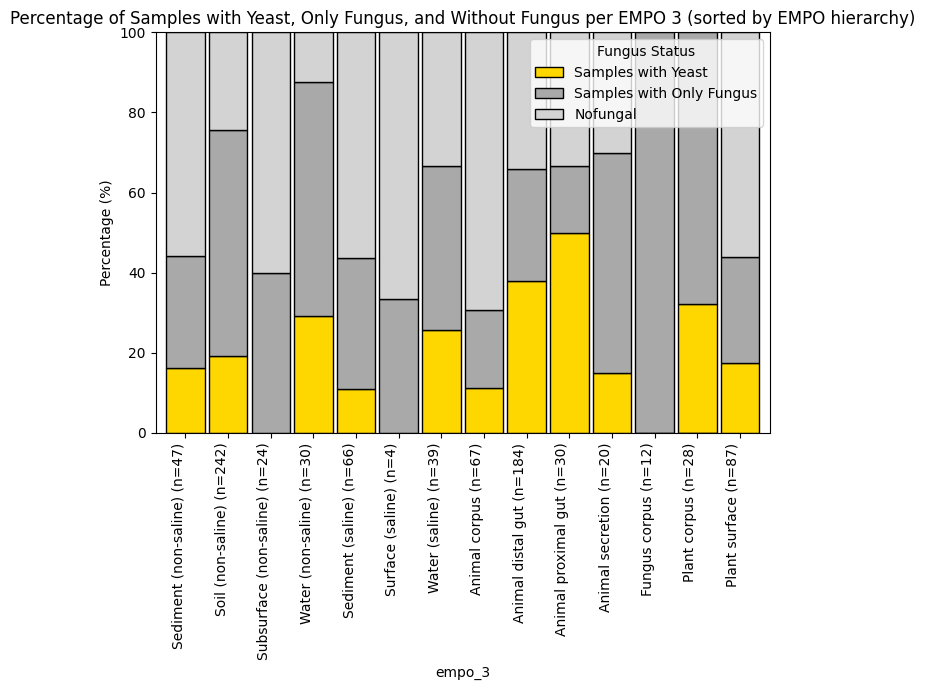

In [ ]:
# Ensure percentage_df is available from cell ROB50TKAC-Kh
# Ensure df_hierarchy is available from previous cells

# Merge percentage_df with df_hierarchy to get EMPO 1 and EMPO 2 for sorting
percentage_df_with_hierarchy = percentage_df.merge(df_hierarchy[['empo_1', 'empo_2']], left_index=True, right_index=True, how='left')

# Sort by EMPO 1 and EMPO 2
percentage_df_sorted = percentage_df_with_hierarchy.sort_values(by=['empo_1', 'empo_2'])

# Select the columns for plotting in the desired order
plot_data = percentage_df_sorted[['Samples with Yeast', 'Samples with Only Fungus', 'Nofungal']] # Assuming 'Samples without Fungus' is equivalent to 'Nofungal'



# Calculate the number of samples per empo_3 category
# Ensure sample counts are aligned with the sorted empo_3 categories for the plot
sample_counts_by_empo3 = df_meta['empo_3'].value_counts()
# Create new labels including sample counts, ensuring the order matches the sorted plot_data index
new_x_labels = [f'{category} (n={sample_counts_by_empo3.get(category, 0)})' for category in plot_data.index]


# Define colors for the stacked bars
colors = ["gold", "darkgray", "lightgray"] # Gold for Yeast, Dark gray for Only Fungus, Light gray for Without Fungus

# Plot stacked bar
ax = plot_data.plot(
    kind="bar",
    stacked=True,
    color=colors,
    edgecolor="black",
    figsize=(7,7),
    width=0.9 # Adjust bar width as needed
)

plt.ylabel("Percentage (%)")
plt.title("Percentage of Samples with Yeast, Only Fungus, and Without Fungus per EMPO 3 (sorted by EMPO hierarchy)")

# Set the new x-axis labels and increase font size
ax.set_xticklabels(new_x_labels, rotation=90, ha="right", fontsize=10)

plt.ylim(0, 100)
plt.legend(title="Fungus Status", loc="upper right")
plt.tight_layout()
plt.show()

## Genus distribution

### **Absolute** analysis

Agglomerating levels isyeast vs is not yeast

Choosing taxonomical level to agglomerate

In [15]:
yeastonly_abundance_df=yeast_abundance_df
yeastonly_abundance_df.loc[yeastonly_abundance_df['isyeast'] == 'N', 'genus'] = 'Non yeast'
yeastonly_abundance_df.loc[yeastonly_abundance_df['isyeast'] == 'tbc', 'genus'] = 'Non yeast'

yeastonly_abundance_df.head(5)

,taxid,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s003,13114.angenent.65.s004,13114.angenent.65.s005,13114.angenent.65.s006,13114.angenent.65.s007,13114.angenent.65.s008,13114.angenent.65.s009,...,phylum,class,order,family,genus,species,subphylum,taxa,result,isyeast
0,2036908,8922.0,0.0,0.0,0.0,0.0,0.0,101.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Non yeast,jacksonii,Pezizomycotina,Clarireedia,No results found,N
1,2860823,4241.0,0.0,0.0,0.0,231.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Non yeast,paspali,Pezizomycotina,Clarireedia,No results found,N
2,2867042,3223.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Non yeast,hainanense,Pezizomycotina,Clarireedia,No results found,N
3,2211668,473.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Non yeast,monteithiana,Pezizomycotina,Clarireedia,No results found,N
4,2086344,9845.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Ascomycota,Leotiomycetes,Erysiphales,Erysiphaceae,Non yeast,cerasi,Pezizomycotina,Podosphaera,No results found,N


In [21]:
# Get the counts of unique values in the 'kingdom' column
subphylum_counts = yeast_abundance_df['subphylum'].value_counts()

# Print the counts
print("Counts of samples per phylum:")
print(subphylum_counts)

Counts of samples per phylum:
subphylum
Pezizomycotina           500
Agaricomycotina          105
Saccharomycotina          76
Mucoromycotina            20
Pucciniomycotina          17
Ustilaginomycotina        16
Mortierellomycotina       16
Glomeromycotina            9
Zoopagomycotina            2
Wallemiomycotina           2
Taphrinomycotina           2
Entomophthoromycotina      1
Name: count, dtype: int64


In [18]:
# Search for the string "unclassified" in the DataFrame
unclassified_locations = yeast_abundance_df.apply(lambda row: row.astype(str).str.contains('unclassified', case=False).any(), axis=1)
rows_with_unclassified = yeast_abundance_df[unclassified_locations]

if not rows_with_unclassified.empty:
    print("Rows containing 'unclassified' (case-insensitive):")
    display(rows_with_unclassified)
else:
    print("No values containing 'unclassified' found in the DataFrame.")

No values containing 'unclassified' found in the DataFrame.


In [ ]:
#yeast_abundance_df[yeast_abundance_df['genus'] == 'Aspergillus']

In [23]:
subphylum_counts = yeastonly_abundance_df['subphylum'].value_counts()
print(subphylum_counts.head())
#Aspergius ?

subphylum
Pezizomycotina      500
Agaricomycotina     105
Saccharomycotina     76
Mucoromycotina       20
Pucciniomycotina     17
Name: count, dtype: int64


In [27]:
# Ensure 'subphylum_' column is available in yeast_abundance_df
if 'subphylum' not in yeastonly_abundance_df.columns:
    print("Error: 'subphylum' column not found in yeast_abundance_df.")
else:
    # Set 'genus' as the index for grouping
    yeast_abundance_indexed_by_subphylum = yeastonly_abundance_df.set_index('subphylum')


In [28]:

# Select only the numeric abundance columns
    # Assuming abundance columns are all columns except taxonomic ones and 'taxid'
columns_to_exclude_from_agg = ['taxid', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'taxa', 'result', 'isyeast']
abundance_columns_yeast = yeast_abundance_indexed_by_subphylum.columns.difference(columns_to_exclude_from_agg)

    # Agglomerate by summing across samples for each subphylum(index)
yeast_subphylum_abundance_df = yeast_abundance_indexed_by_subphylum[abundance_columns_yeast].sum(axis=0).to_frame().T # Sum across rows (taxa within genus), then transpose

    # Wait, the user wants to sum across samples for each subphylum.
    # The index should be subphylum, columns should be samples.
    # Let's redo the aggregation correctly.

    # Agglomerate by grouping by the 'subphylum' index and summing the numeric columns
yeast_subphylum_abundance_df = yeast_abundance_indexed_by_subphylum[abundance_columns_yeast].groupby(yeast_abundance_indexed_by_subphylum.index).sum()


    # Display the head of the agglomerated DataFrame
print("Yeast Abundance Agglomerated by subphylum:")
display(yeast_subphylum_abundance_df.head())

Yeast Abundance Agglomerated by subphylum:


,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s003,13114.angenent.65.s004,13114.angenent.65.s005,13114.angenent.65.s006,13114.angenent.65.s007,13114.angenent.65.s008,13114.angenent.65.s009,13114.berry.2.s001,...,13114.zaneveld.9.s013,13114.zaneveld.9.s014,13114.zaneveld.9.s015,13114.zaneveld.9.s016,13114.zaneveld.9.s017,13114.zaneveld.9.s018,13114.zaneveld.9.s019,13114.zaneveld.9.s020,13114.zaneveld.9.s021,13114.zaneveld.9.s022
subphylum,,,,,,,,,,,,,,,,,,,,,
Agaricomycotina,958.0,156.0,0.0,0.0,77.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15603.0,9826.0
Entomophthoromycotina,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Glomeromycotina,657.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Mortierellomycotina,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Mucoromycotina,9306.0,996.0,0.0,0.0,3730.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,135.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
rows, cols = yeast_subphylum_abundance_df.shape
print(f"The DataFrame has {rows} rows and {cols} columns.")

The DataFrame has 12 rows and 750 columns.


In [30]:
# Ensure only numeric columns are included in the sum
numeric_columns_yeast_subphylum = yeast_subphylum_abundance_df.select_dtypes(include=np.number).columns

# Calculate the total abundance for each subphylum across all samples
total_subphylum_abundance = yeast_subphylum_abundance_df[numeric_columns_yeast_subphylum].sum(axis=1)

# Sort the total subphylum abundance in descending order
sorted_total_subphylum_abundance = total_subphylum_abundance.sort_values(ascending=False)

# Display the sorted total subphylum abundance
print("Total Absolute Abundance of Each Yeast subphylum Across Samples (Sorted):")
display(sorted_total_subphylum_abundance.head())

Total Absolute Abundance of Each Yeast subphylum Across Samples (Sorted):


,0
subphylum,
Agaricomycotina,59737228.0
Pezizomycotina,32054846.0
Saccharomycotina,7067749.0
Mucoromycotina,4770736.0
Pucciniomycotina,1920638.0


subphylum
Agaricomycotina     59737228.0
Pezizomycotina      32054846.0
Saccharomycotina     7067749.0
Mucoromycotina       4770736.0
Pucciniomycotina     1920638.0
dtype: float64


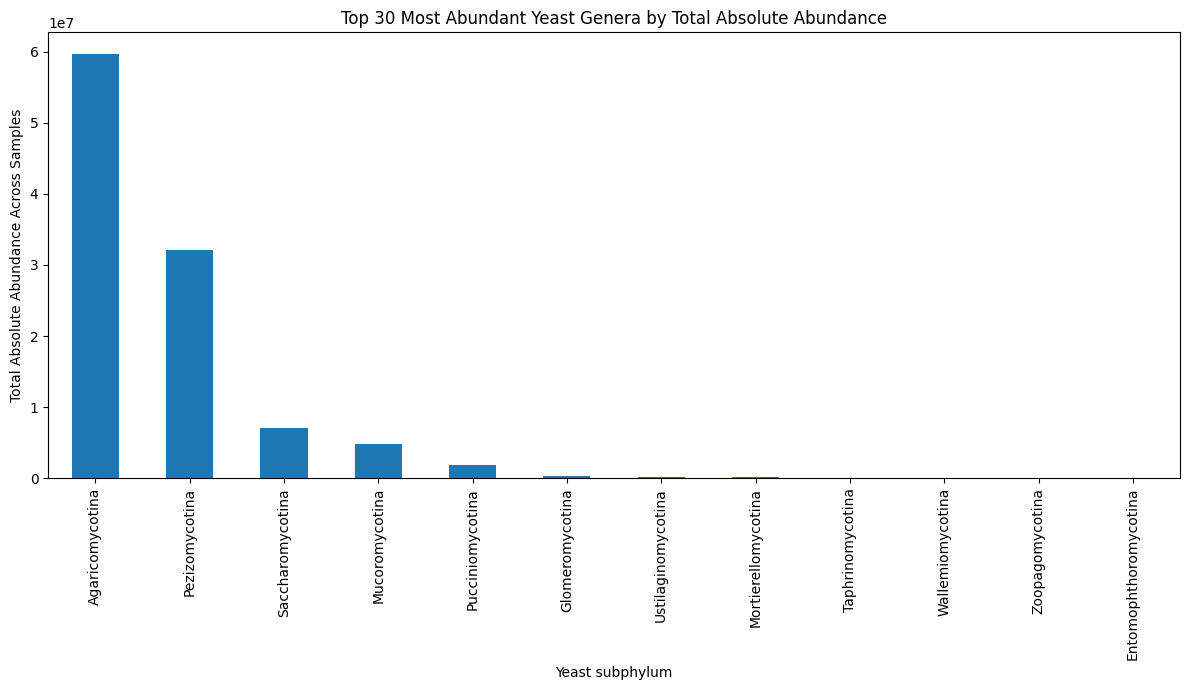

In [31]:
# Ensure only numeric columns are included in the sum
numeric_columns_yeast_subphylum = yeast_subphylum_abundance_df.select_dtypes(include=np.number).columns

# Calculate the total abundance for each subphylum across all samples
total_subphylum_abundance = yeast_subphylum_abundance_df[numeric_columns_yeast_subphylum].sum(axis=1)

# Remove the 'Non yeast' row
total_subphylum_abundance  = total_subphylum_abundance.drop('Non yeast', errors='ignore')

# Get the top 30 most abundant genera by total abundance
top30_yeast_genera_abundance = total_subphylum_abundance.nlargest(30)
print(top30_yeast_genera_abundance.head())

# Plot a bar chart of the top 30 genera total abundance
ax = top30_yeast_genera_abundance.plot(kind='bar', figsize=(12, 7))

ax.set_xlabel("Yeast subphylum")
ax.set_ylabel("Total Absolute Abundance Across Samples")
ax.set_title("Top 30 Most Abundant Yeast Genera by Total Absolute Abundance")
plt.tight_layout()
plt.show()

##### Carefully manually checking Saccharomyces

In [35]:
# Ensure yeast_genus_abundance_df and df_meta are available from previous cells

# Transpose the genus abundance DataFrame so samples are rows
subphylum_abundance_T = yeast_subphylum_abundance_df.T

# Select the 'empo_3' column from the metadata
empo3_metadata = df_meta[['empo_3']]

# Merge the transposed subphylum abundance DataFrame with the empo_3 metadata
# The merge will happen on the index (sample names)
merged_for_grouping_absolute = subphylum_abundance_T.merge(empo3_metadata, left_index=True, right_index=True, how='left')

# Group by 'empo_3' and calculate the sum of 'Agaricomycotina' abundance for each empo_3 group
# Make sure 'Agaricomycotina' is a column in the merged DataFrame
if 'Agaricomycotina' in merged_for_grouping_absolute.columns:
    Agaricomycotina_abundance_by_empo3 = merged_for_grouping_absolute.groupby('empo_3')['Agaricomycotina'].sum()

    # Display the resulting Series
    print("Total Absolute Abundance of Agaricomycotina per EMPO 3 Category:")
    display(Agaricomycotina_abundance_by_empo3)

    # Calculate and print the overall total sum of Agaricomycotina reads
    overall_total_Agaricomycotina_abundance = Agaricomycotina_abundance_by_empo3.sum()
    print(f"\nOverall total absolute abundance of Agaricomycotina across all EMPO 3 categories: {overall_total_Agaricomycotina_abundance}")
else:
    print("'Agaricomycotina' subphylum not found in the abundance data after merging.")

Total Absolute Abundance of Agaricomycotina per EMPO 3 Category:


,Agaricomycotina
empo_3,
Animal corpus,55175.0
Animal distal gut,11493738.0
Animal proximal gut,1191.0
Animal secretion,1157.0
Fungus corpus,117488.0
Plant corpus,47598749.0
Plant surface,66923.0
Sediment (non-saline),27478.0
Sediment (saline),19075.0



Overall total absolute abundance of Agaricomycotina across all EMPO 3 categories: 59737228.0


In [37]:
#Filter df_meta to get sample names for 'Animal distal gut'
animal_distal_gut_samples_in_meta = df_meta[df_meta['empo_3'] == 'Animal distal gut'].index

# Get the intersection of sample IDs from metadata and the columns of yeast_subphylum_abundance_df
animal_distal_gut_samples = animal_distal_gut_samples_in_meta.intersection(yeast_subphylum_abundance_df.columns)

# Filter yeast_subphylum_abundance_df to select only the 'Agaricomycotina' row and the 'Animal distal gut' samples
Agaricomycotina_abundance_animal_distal_gut = yeast_subphylum_abundance_df.loc['Agaricomycotina', animal_distal_gut_samples]

# Sort the abundance values from more to less abundance
Agaricomycotina_abundance_animal_distal_gut_sorted = Agaricomycotina_abundance_animal_distal_gut.sort_values(ascending=False)

# Print the sorted abundance data
print("Absolute abundance of Agaricomycotina by sample in 'Animal distal gut' EMPO 3 category (Sorted):")
display(Agaricomycotina_abundance_animal_distal_gut_sorted)

# Calculate the total sum of reads for Agaricomycotina in this category
total_Agaricomycotina_abundance_animal_distal_gut = Agaricomycotina_abundance_animal_distal_gut.sum()

# Print the total sum of reads
print(f"\nTotal absolute abundance of Agaricomycotina in 'Animal distal gut' samples: {total_Agaricomycotina_abundance_animal_distal_gut}")

Absolute abundance of Agaricomycotina by sample in 'Animal distal gut' EMPO 3 category (Sorted):


,Agaricomycotina
13114.mousseau.88.s011,10981465.0
13114.mousseau.88.s062,186179.0
13114.mousseau.88.s016,114755.0
13114.song.51.s011,43856.0
13114.song.52.s013,33685.0
...,...
13114.song.53.s007,0.0
13114.song.53.s011,0.0
13114.song.53.s010,0.0
13114.song.53.s009,0.0



Total absolute abundance of Agaricomycotina in 'Animal distal gut' samples: 11493738.0


##### Now producing graph of  yeast vs no **yeast**

In [38]:
# We need to use the sample metadata to group the samples.
# Ensure the index of the metadata DataFrame (df_meta) is the sample names.
# Select the 'empo_3' column from the metadata
empo3_metadata = df_meta[['empo_3']]

# Transpose the subphylum abundance DataFrame so samples are rows
subphylum_abundance_T = yeast_subphylum_abundance_df.T

# Check if subphylum_abundance_T is a Series and convert to DataFrame if necessary
if isinstance(subphylum_abundance_T, pd.Series):
    print("Warning: subphylum_abundance_T is a Series. Converting to DataFrame.")
    # Convert Series to DataFrame, using a generic column name (assuming the single column contains abundance)
    subphylum_abundance_T = subphylum_abundance_T.to_frame(name='Abundance')


# Merge the transposed subphylum abundance DataFrame with the empo_3 metadata
# The merge will happen on the index (sample names)
merged_for_grouping_absolute = subphylum_abundance_T.merge(empo3_metadata, left_index=True, right_index=True, how='left')

# Identify the subphylum abundance columns in the merged DataFrame
# These should be the columns from subphylum_abundance_T, excluding 'empo_3'
subphylum_abundance_columns_in_merged = merged_for_grouping_absolute.columns.difference(['empo_3'])

# Now, group by 'empo_3' and calculate the sum of absolute abundance for each subphylum within each empo_3 group
# Explicitly select the subphylum abundance columns for summation
grouped_absolute_abundance_by_empo3 = merged_for_grouping_absolute.groupby('empo_3')[subphylum_abundance_columns_in_merged].sum()

#-------Sorting-------
# Merge percentage_df with df_hierarchy to get EMPO 1 and EMPO 2 for sorting
absolute_df_with_hierarchy = grouped_absolute_abundance_by_empo3.merge(df_hierarchy[['empo_1', 'empo_2']], left_index=True, right_index=True, how='left')
# Sort by EMPO 1 and EMPO 2
grouped_absolute_abundance_by_empo3 = absolute_df_with_hierarchy.sort_values(by=['empo_1', 'empo_2'])

#print(grouped_absolute_abundance_by_empo3.head(5))
grouped_absolute_abundance_by_empo3.head(5)
#print(df_hierarchy.head(5))

grouped_absolute_abundance_by_empo3 = grouped_absolute_abundance_by_empo3.iloc[:, :-2]
#-------End of Sorting-------

grouped_absolute_abundance_by_empo3.head(5)


,Agaricomycotina,Entomophthoromycotina,Glomeromycotina,Mortierellomycotina,Mucoromycotina,Pezizomycotina,Pucciniomycotina,Saccharomycotina,Taphrinomycotina,Ustilaginomycotina,Wallemiomycotina,Zoopagomycotina
empo_3,,,,,,,,,,,,
Sediment (non-saline),27478.0,0.0,100.0,0.0,8580.0,294867.0,1762.0,97100.0,0.0,4576.0,0.0,503.0
Soil (non-saline),321766.0,166.0,215143.0,140085.0,3396984.0,3517744.0,318690.0,460607.0,0.0,24655.0,0.0,44.0
Subsurface (non-saline),189.0,0.0,0.0,0.0,0.0,1065.0,0.0,0.0,0.0,0.0,0.0,0.0
Water (non-saline),946.0,0.0,3424.0,0.0,50560.0,268210.0,7778.0,78038.0,0.0,853.0,0.0,0.0
Sediment (saline),19075.0,0.0,0.0,0.0,19986.0,1882553.0,1935.0,13066.0,0.0,2388.0,0.0,1010.0


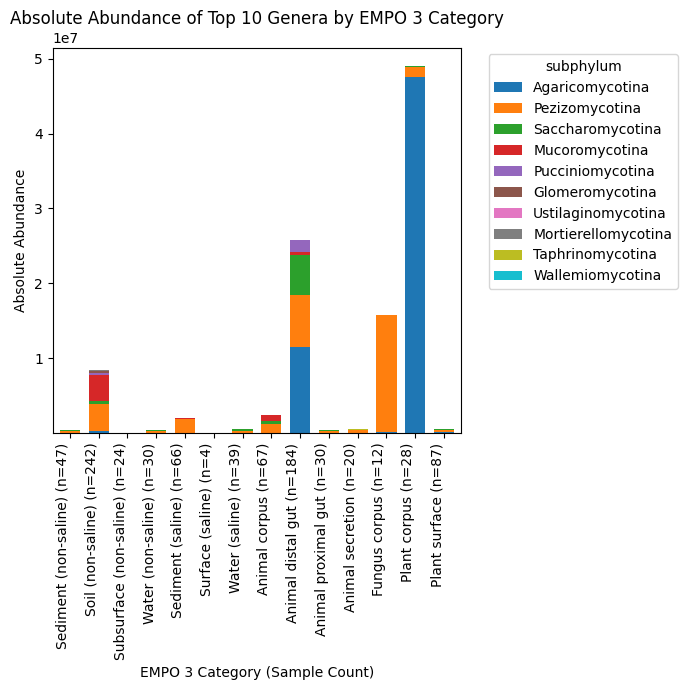

In [39]:

# To make the plot readable, let's select the top genera based on their total absolute abundance across all empo_3 groups
top10_genera_absolute_grouped = grouped_absolute_abundance_by_empo3.sum().nlargest(10).index
top10_genera_absolute_grouped

# Filter the grouped absolute abundance DataFrame to include only the top 10 genera
plot_data_absolute_grouped = grouped_absolute_abundance_by_empo3[top10_genera_absolute_grouped]

# Calculate the number of samples per empo_3 category
# Ensure sample counts are aligned with the sorted empo_3 categories for the plot
sample_counts_by_empo3 = df_meta['empo_3'].value_counts()
# Create new labels including sample counts, ensuring the order matches the sorted plot_data_absolute_grouped index
new_x_labels = [f'{category} (n={sample_counts_by_empo3.get(category, 0)})' for category in plot_data_absolute_grouped.index]


# Plotting
ax = plot_data_absolute_grouped.plot(kind='bar', stacked=True, figsize=(7, 7),
                                     width=.7)
ax.set_xlabel("EMPO 3 Category (Sample Count)")
ax.set_ylabel("Absolute Abundance")
ax.set_title("Absolute Abundance of Top 10 Genera by EMPO 3 Category")
ax.legend(title="subphylum", bbox_to_anchor=(1.05, 1), loc='upper left')

# Set the new x-axis labels
ax.set_xticklabels(new_x_labels, rotation=90, ha='right')

plt.tight_layout()
plt.show()

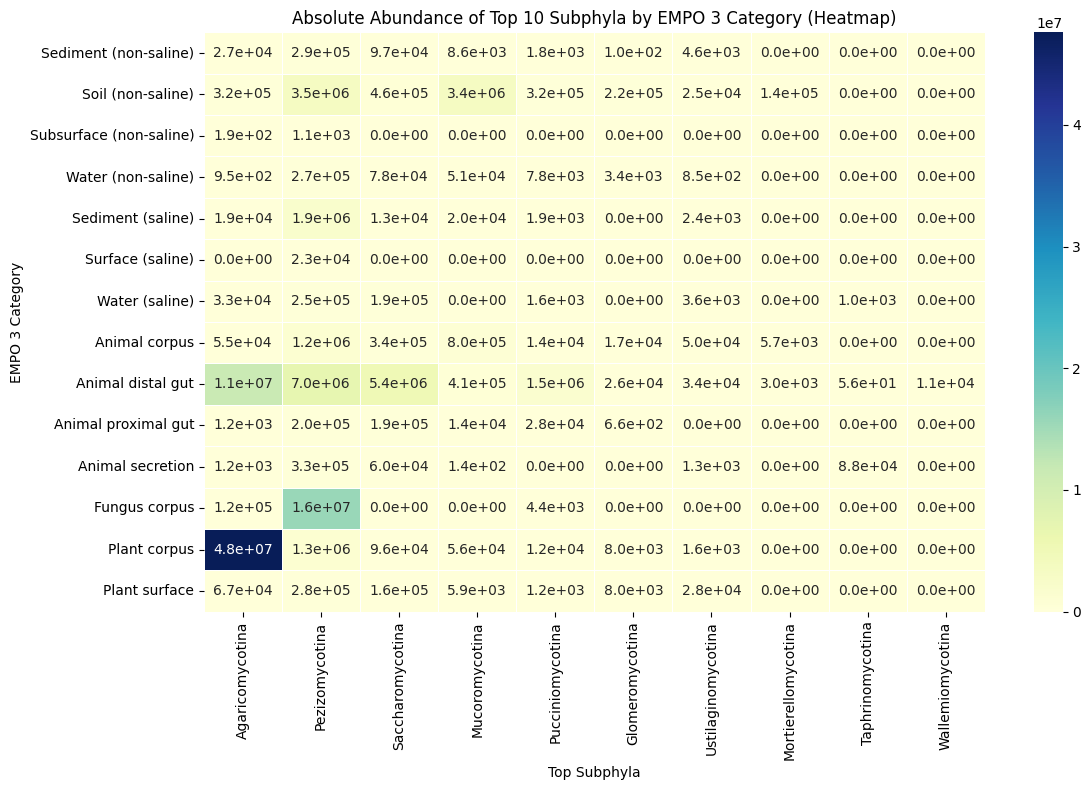

In [40]:
import seaborn as sns

# Ensure grouped_absolute_abundance_by_empo3 is available from previous cells

# Select the top N subphyla based on total absolute abundance across all EMPO 3 categories
top_n_subphyla = 10 # You can adjust this number
top_subphyla_absolute_grouped = grouped_absolute_abundance_by_empo3.sum().nlargest(top_n_subphyla).index

# Filter the grouped absolute abundance DataFrame to include only the top subphyla
heatmap_data_absolute = grouped_absolute_abundance_by_empo3[top_subphyla_absolute_grouped]

# Sort the heatmap data by EMPO 1 and EMPO 2 categories for better visualization
# Ensure df_hierarchy is available from previous cells
heatmap_data_absolute = heatmap_data_absolute.merge(df_hierarchy[['empo_1', 'empo_2']], left_index=True, right_index=True, how='left')
heatmap_data_absolute = heatmap_data_absolute.sort_values(by=['empo_1', 'empo_2'])
heatmap_data_absolute = heatmap_data_absolute.drop(columns=['empo_1', 'empo_2']) # Drop the hierarchy columns after sorting


# Plotting the heatmap
plt.figure(figsize=(12, 8)) # Adjust figure size as needed
sns.heatmap(heatmap_data_absolute, annot=True, fmt=".1e", cmap="YlGnBu", linewidths=.5)

plt.xlabel("Top Subphyla")
plt.ylabel("EMPO 3 Category")
plt.title(f"Absolute Abundance of Top {top_n_subphyla} Subphyla by EMPO 3 Category (Heatmap)")
plt.tight_layout()
plt.show()

In [43]:
# Filter the yeast_abundance_df to find rows where the genus is 'Saccharomyces'
saccharomyces_info = yeast_abundance_df[yeast_abundance_df['genus'] == 'Saccharomyces']

# Get the unique subphylum values for Saccharomyces
saccharomyces_subphylum = saccharomyces_info['subphylum'].unique()

# Print the subphylum
print(f"The subphylum of Saccharomyces is: {saccharomyces_subphylum}")

The subphylum of Saccharomyces is: ['Saccharomycotina']


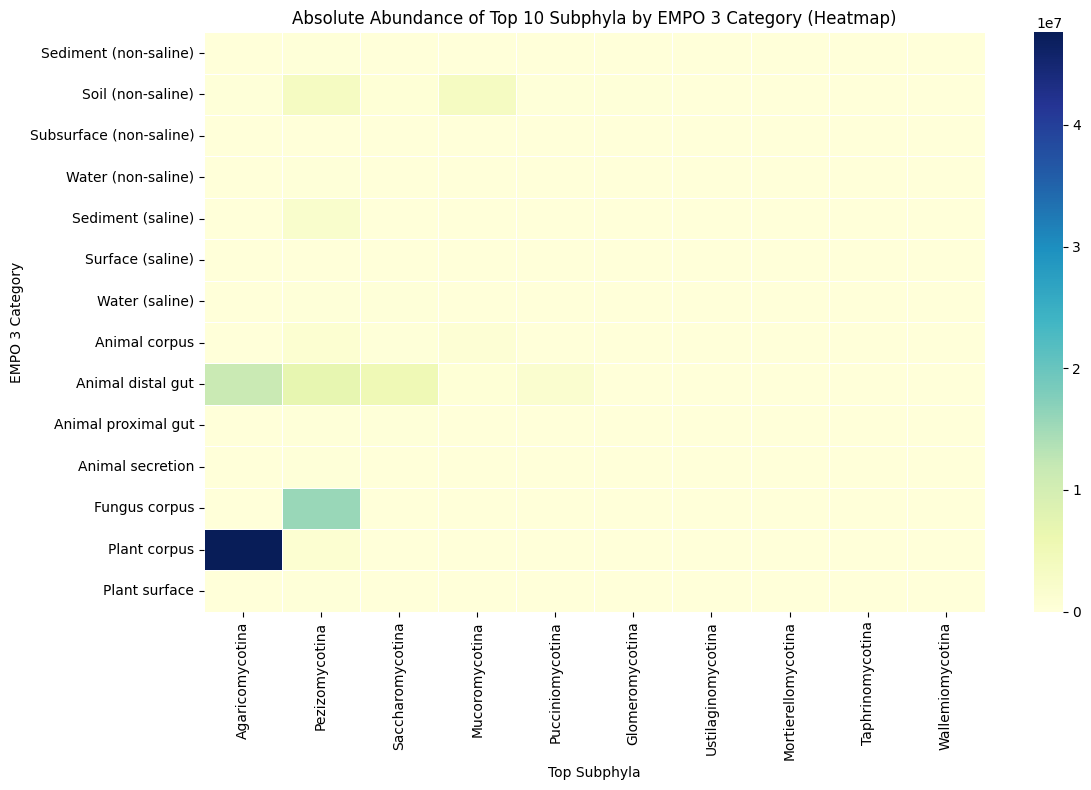

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure grouped_absolute_abundance_by_empo3 is available from previous cells

# Select the top N subphyla based on total absolute abundance across all EMPO 3 categories
top_n_subphyla = 10 # You can adjust this number
top_subphyla_absolute_grouped = grouped_absolute_abundance_by_empo3.sum().nlargest(top_n_subphyla).index

# Filter the grouped absolute abundance DataFrame to include only the top subphyla
heatmap_data_absolute = grouped_absolute_abundance_by_empo3[top_subphyla_absolute_grouped]

# Sort the heatmap data by EMPO 1 and EMPO 2 categories for better visualization
# Ensure df_hierarchy is available from previous cells
heatmap_data_absolute = heatmap_data_absolute.merge(df_hierarchy[['empo_1', 'empo_2']], left_index=True, right_index=True, how='left')
heatmap_data_absolute = heatmap_data_absolute.sort_values(by=['empo_1', 'empo_2'])
heatmap_data_absolute = heatmap_data_absolute.drop(columns=['empo_1', 'empo_2']) # Drop the hierarchy columns after sorting


# Plotting the heatmap
plt.figure(figsize=(12, 8)) # Adjust figure size as needed
sns.heatmap(heatmap_data_absolute, annot=False, fmt=".1e", cmap="YlGnBu", linewidths=.5) # Removed annot=True

plt.xlabel("Top Subphyla")
plt.ylabel("EMPO 3 Category")
plt.title(f"Absolute Abundance of Top {top_n_subphyla} Subphyla by EMPO 3 Category (Heatmap)")
plt.tight_layout()
plt.show()

##### Now producing graph of yeast without no **yeast**

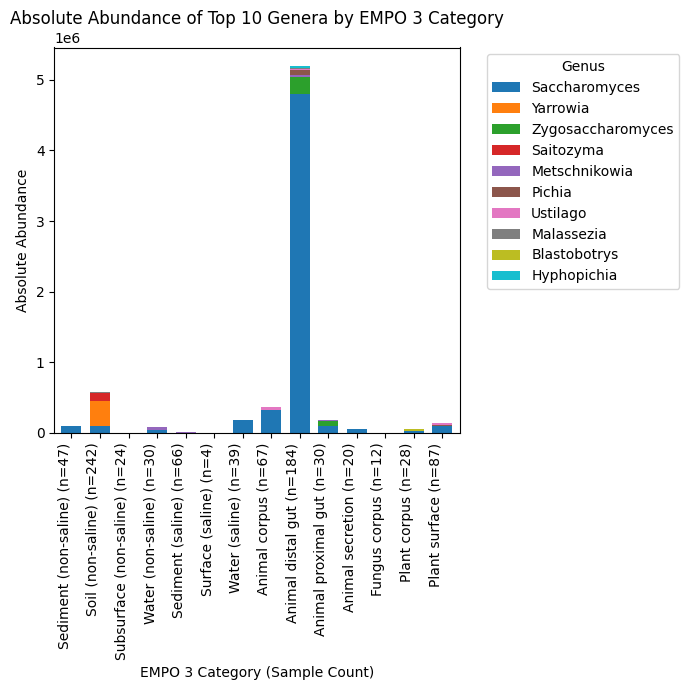

In [ ]:
top10_genera_absolute_grouped

# To make the plot readable, let's select the top genera based on their total absolute abundance across all empo_3 groups
top11_genera_absolute_grouped = grouped_absolute_abundance_by_empo3.sum().nlargest(11).index
top10_genera_absolute_grouped = top11_genera_absolute_grouped.drop('Non yeast', errors='ignore')

## Drop Non Yeast
top10_genera_absolute_grouped = top11_genera_absolute_grouped.drop('Non yeast', errors='ignore')

# Filter the grouped absolute abundance DataFrame to include only the top 10 genera
plot_data_absolute_grouped = grouped_absolute_abundance_by_empo3[top10_genera_absolute_grouped]

# Calculate the number of samples per empo_3 category
# Ensure sample counts are aligned with the sorted empo_3 categories for the plot
sample_counts_by_empo3 = df_meta['empo_3'].value_counts()
# Create new labels including sample counts, ensuring the order matches the sorted plot_data_absolute_grouped index
new_x_labels = [f'{category} (n={sample_counts_by_empo3.get(category, 0)})' for category in plot_data_absolute_grouped.index]


# Plotting
ax = plot_data_absolute_grouped.plot(kind='bar', stacked=True, figsize=(7, 7),
                                     width=.7)
ax.set_xlabel("EMPO 3 Category (Sample Count)")
ax.set_ylabel("Absolute Abundance")
ax.set_title("Absolute Abundance of Top 10 Genera by EMPO 3 Category")
ax.legend(title="Genus", bbox_to_anchor=(1.05, 1), loc='upper left')

# Set the new x-axis labels
ax.set_xticklabels(new_x_labels, rotation=90, ha='right')

plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

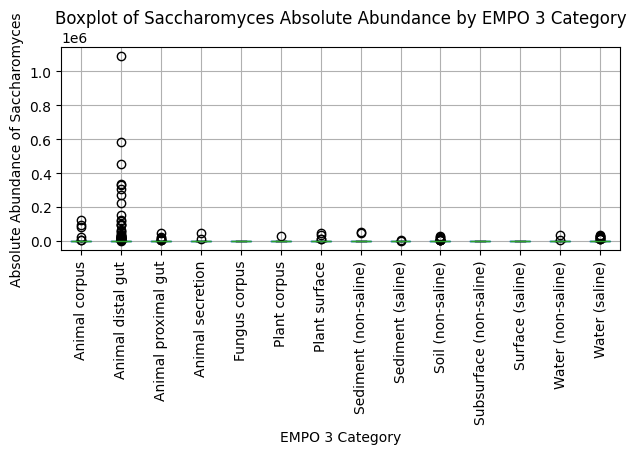

In [ ]:
# Ensure yeast_genus_abundance_df and df_meta are available from previous cells

# Select the 'Saccharomyces' column from the transposed abundance data
saccharomyces_abundance_samples = genus_abundance_T[['Saccharomyces']]

# Merge the Saccharomyces abundance data with the empo_3 metadata
# The merge will happen on the index (sample names)
merged_saccharomyces_absolute = saccharomyces_abundance_samples.merge(empo3_metadata, left_index=True, right_index=True, how='inner')

# Drop any rows with missing EMPO 3 data after merging
merged_saccharomyces_absolute = merged_saccharomyces_absolute.dropna(subset=['empo_3'])

# Create the boxplot using the merged DataFrame
plt.figure(figsize=(12, 7))
merged_saccharomyces_absolute.boxplot(column='Saccharomyces', by='empo_3', rot=90)

plt.xlabel("EMPO 3 Category")
plt.ylabel("Absolute Abundance of Saccharomyces")
plt.title("Boxplot of Saccharomyces Absolute Abundance by EMPO 3 Category")
plt.suptitle("") # Suppress the default suptitle created by pandas plot
plt.tight_layout()
plt.show()

### Relative abundace

This is relative to the numbers of reads that classified as fungus. Which could be really different in percentage from sample to sample, not as in bacteria that most of them are bacteria.

In [ ]:
# Ensure yeast_genus_abundance_df is available from previous cells

# Ensure only numeric columns are included in the calculation
numeric_columns_yeast_genus = yeast_genus_abundance_df.select_dtypes(include=np.number).columns

# Calculate relative abundance by dividing by the sum of abundances for each sample (column)
yeast_genus_relative_abundance_df = yeast_genus_abundance_df[numeric_columns_yeast_genus].apply(lambda x: x / x.sum(), axis=0)

# Fill NaN values with 0
yeast_genus_relative_abundance_df = yeast_genus_relative_abundance_df.fillna(0)


# Display the head of the relative abundance DataFrame
print("Yeast Genus Relative Abundance DataFrame (per sample):")
display(yeast_genus_relative_abundance_df.head())

Yeast Genus Relative Abundance DataFrame (per sample):


,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s003,13114.angenent.65.s004,13114.angenent.65.s005,13114.angenent.65.s006,13114.angenent.65.s007,13114.angenent.65.s008,13114.angenent.65.s009,13114.berry.2.s001,...,13114.zaneveld.9.s013,13114.zaneveld.9.s014,13114.zaneveld.9.s015,13114.zaneveld.9.s016,13114.zaneveld.9.s017,13114.zaneveld.9.s018,13114.zaneveld.9.s019,13114.zaneveld.9.s020,13114.zaneveld.9.s021,13114.zaneveld.9.s022
genus,,,,,,,,,,,,,,,,,,,,,
Blastobotrys,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bullera,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Candida,0.0,0.0,0.083979,0.033521,0.0,0.0,0.0,0.010529,0.0,0.0,...,0.0,0.0,0.002738,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clavispora,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cyberlindnera,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Ensure yeast_genus_relative_abundance_df is available from previous cells

# Sum the relative abundance across samples for each genus
total_relative_abundance_per_genus = yeast_genus_relative_abundance_df.sum(axis=1)

# Sort the genera by total relative abundance in descending order
sorted_total_relative_abundance = total_relative_abundance_per_genus.sort_values(ascending=False)

# Display the sorted total relative abundance
print("Total Relative Abundance of Each Yeast Genus Across Samples (Sorted):")
display(sorted_total_relative_abundance.head())

Total Relative Abundance of Each Yeast Genus Across Samples (Sorted):


,0
genus,
Non yeast,404.247964
Saccharomyces,42.216415
Zygosaccharomyces,10.607966
Saitozyma,5.878423
Pichia,2.006022


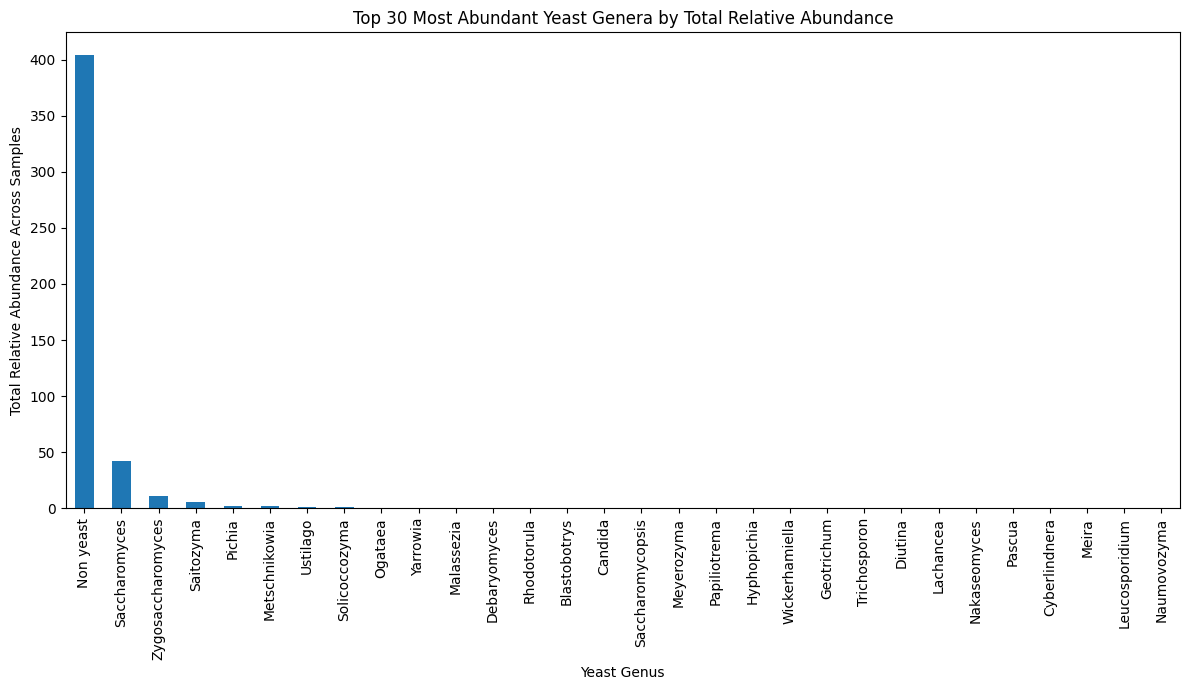

In [ ]:
# Ensure sorted_total_relative_abundance is available from cell 2LzqeBHIiucS

# Get the top 30 genera by total relative abundance
top30_yeast_genera_relative_abundance = sorted_total_relative_abundance.nlargest(30)

# Plot a bar chart of the top 30 genera total relative abundance
ax = top30_yeast_genera_relative_abundance.plot(kind='bar', figsize=(12, 7))

ax.set_xlabel("Yeast Genus")
ax.set_ylabel("Total Relative Abundance Across Samples")
ax.set_title("Top 30 Most Abundant Yeast Genera by Total Relative Abundance")
plt.tight_layout()
plt.show()

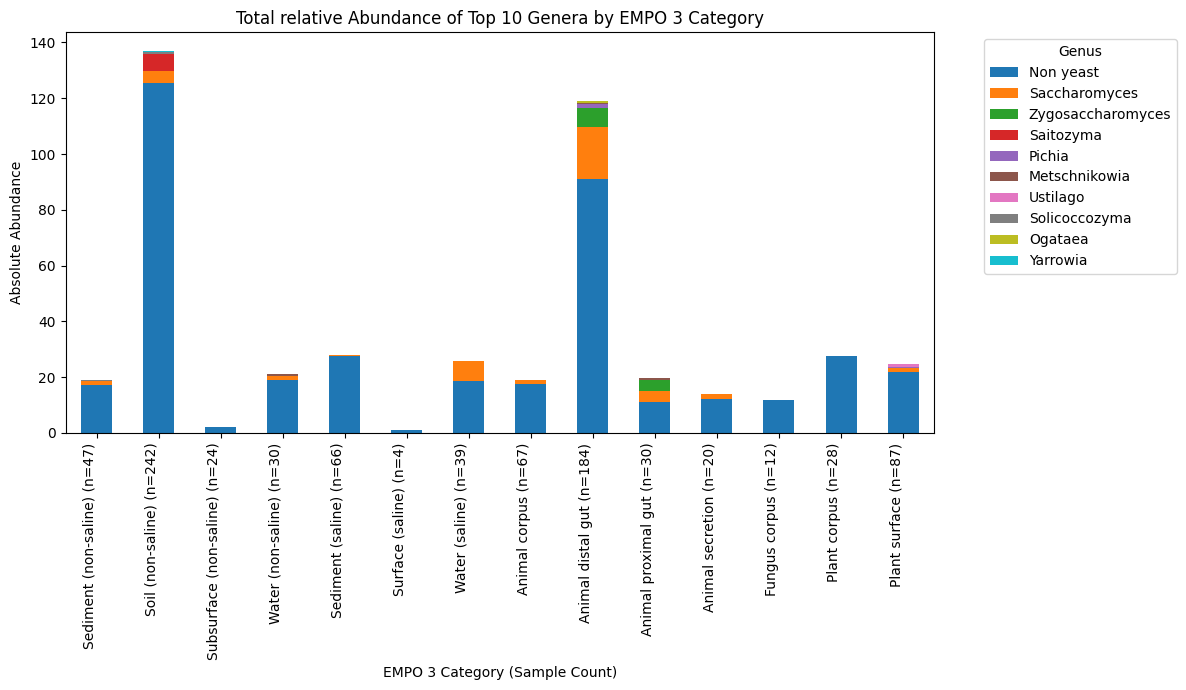

In [ ]:
# We need to use the sample metadata to group the samples.
# Ensure the index of the metadata DataFrame (df_meta) is the sample names.
# Select the 'empo_3' column from the metadata
empo3_metadata = df_meta[['empo_3']]

# Transpose the genus abundance DataFrame so samples are rows
genus_abundance_T = yeast_genus_relative_abundance_df .T

# Check if genus_abundance_T is a Series and convert to DataFrame if necessary
if isinstance(genus_abundance_T, pd.Series):
    print("Warning: genus_abundance_T is a Series. Converting to DataFrame.")
    # Convert Series to DataFrame, using a generic column name (assuming the single column contains abundance)
    genus_abundance_T = genus_abundance_T.to_frame(name='Abundance')


# Merge the transposed genus abundance DataFrame with the empo_3 metadata
# The merge will happen on the index (sample names)
merged_for_grouping_absolute = genus_abundance_T.merge(empo3_metadata, left_index=True, right_index=True, how='left')

# Identify the genus abundance columns in the merged DataFrame
# These should be the columns from genus_abundance_T, excluding 'empo_3'
genus_abundance_columns_in_merged = merged_for_grouping_absolute.columns.difference(['empo_3'])


# Now, group by 'empo_3' and calculate the sum of absolute abundance for each genus within each empo_3 group
# Explicitly select the genus abundance columns for summation
grouped_absolute_abundance_by_empo3 = merged_for_grouping_absolute.groupby('empo_3')[genus_abundance_columns_in_merged].sum()


#-------Sorting-------
# Merge percentage_df with df_hierarchy to get EMPO 1 and EMPO 2 for sorting
absolute_df_with_hierarchy = grouped_absolute_abundance_by_empo3.merge(df_hierarchy[['empo_1', 'empo_2']], left_index=True, right_index=True, how='left')
# Sort by EMPO 1 and EMPO 2
grouped_absolute_abundance_by_empo3 = absolute_df_with_hierarchy.sort_values(by=['empo_1', 'empo_2'])

#print(grouped_absolute_abundance_by_empo3.head(5))
grouped_absolute_abundance_by_empo3.head(5)
#print(df_hierarchy.head(5))

grouped_absolute_abundance_by_empo3 = grouped_absolute_abundance_by_empo3.iloc[:, :-2]
#-------End of Sorting-------


# To make the plot readable, let's select the top genera based on their total absolute abundance across all empo_3 groups
top10_genera_absolute_grouped = grouped_absolute_abundance_by_empo3.sum().nlargest(10).index

# Filter the grouped absolute abundance DataFrame to include only the top 10 genera
plot_data_absolute_grouped = grouped_absolute_abundance_by_empo3[top10_genera_absolute_grouped]

# Calculate the number of samples per empo_3 category
# Ensure sample counts are aligned with the sorted empo_3 categories for the plot
sample_counts_by_empo3 = df_meta['empo_3'].value_counts()
# Create new labels including sample counts, ensuring the order matches the sorted plot_data_absolute_grouped index
new_x_labels = [f'{category} (n={sample_counts_by_empo3.get(category, 0)})' for category in plot_data_absolute_grouped.index]


# Plotting
ax = plot_data_absolute_grouped.plot(kind='bar', stacked=True, figsize=(12, 7))
ax.set_xlabel("EMPO 3 Category (Sample Count)")
ax.set_ylabel("Absolute Abundance")
ax.set_title("Total relative Abundance of Top 10 Genera by EMPO 3 Category")
ax.legend(title="Genus", bbox_to_anchor=(1.05, 1), loc='upper left')

# Set the new x-axis labels
ax.set_xticklabels(new_x_labels, rotation=90, ha='right')

plt.tight_layout()
plt.show()

Last graph were only exploratory, in this section the main result is the matrix: yeast_genus_relative_abundance_df

### Mean Relative abundance

In [ ]:
# Ensure yeast_genus_relative_abundance_df is available from previous cells
# Ensure df_meta is available from previous cells
# Transpose the relative abundance DataFrame so samples are rows and genera are columns
yeast_genus_relative_abundance_T = yeast_genus_relative_abundance_df.T

# Merge the transposed relative abundance DataFrame with the empo_3 metadata
# The merge will happen on the index (sample names)
merged_for_grouping_yeast = yeast_genus_relative_abundance_T.merge(empo3_metadata, left_index=True, right_index=True, how='left')

# Group by 'empo_3' and calculate the mean relative abundance for each genus
grouped_mean_relative_abundance_yeast = merged_for_grouping_yeast.groupby('empo_3').mean()

# Transpose the result to have genus as index and empo_3 as columns
mean_relative_abundance_by_empo3_yeast = grouped_mean_relative_abundance_yeast.T

# Display the head of the resulting DataFrame
print("Mean Relative Abundance of Yeast Genera by EMPO 3 Category:")
display(mean_relative_abundance_by_empo3_yeast.head())

Mean Relative Abundance of Yeast Genera by EMPO 3 Category:


empo_3,Animal corpus,Animal distal gut,Animal proximal gut,Animal secretion,Fungus corpus,Plant corpus,Plant surface,Sediment (non-saline),Sediment (saline),Soil (non-saline),Subsurface (non-saline),Surface (saline),Water (non-saline),Water (saline)
Blastobotrys,0.000000,9.652788e-06,0.000000,0.000000,0.0,0.005717,0.0,0.000000,0.0,5.207451e-04,0.0,0.0,0.0,0.0
Bullera,0.000000,5.607430e-07,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,5.000415e-07,0.0,0.0,0.0,0.0
Candida,0.000053,2.846812e-04,0.004454,0.000137,0.0,0.000000,0.0,0.000214,0.0,1.219419e-05,0.0,0.0,0.0,0.0
Clavispora,0.000000,2.127959e-05,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.0
Cyberlindnera,0.000000,1.683488e-04,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.0


In [ ]:
# Ensure yeast_genus_relative_abundance_df is available from previous cells

# Sum the relative abundance across samples for each genus
genus_mean_relative_abundance_by_empo3_yeast = mean_relative_abundance_by_empo3_yeast.sum(axis=1)

# Sort the genera by total relative abundance in descending order
sorted_total_mean_relative_abundance = genus_mean_relative_abundance_by_empo3_yeast.sort_values(ascending=False)

# Display the sorted total relative abundance
print("Total Relative Abundance of Each Yeast Genus Across Samples (Sorted):")
display(sorted_total_mean_relative_abundance.head())

Total Relative Abundance of Each Yeast Genus Across Samples (Sorted):


,0
Non yeast,7.656126
Saccharomyces,0.687930
Zygosaccharomyces,0.164067
Metschnikowia,0.056379
Saitozyma,0.032477


In [ ]:
# We need to use the sample metadata to group the samples.
# Ensure the index of the metadata DataFrame (df_meta) is the sample names.


# Transpose the genus abundance DataFrame so samples are rows
genus_abundance_T = mean_relative_abundance_by_empo3_yeast.T

# Check if genus_abundance_T is a Series and convert to DataFrame if necessary
if isinstance(genus_abundance_T, pd.Series):
    print("Warning: genus_abundance_T is a Series. Converting to DataFrame.")
    # Convert Series to DataFrame, using a generic column name (assuming the single column contains abundance)
    genus_abundance_T = genus_abundance_T.to_frame(name='Abundance')

#-------Sorting-------
# Merge percentage_df with df_hierarchy to get EMPO 1 and EMPO 2 for sorting
MeanRelative_df_with_hierarchy = genus_abundance_T.merge(df_hierarchy[['empo_1', 'empo_2']], left_index=True, right_index=True, how='left')
# Sort by EMPO 1 and EMPO 2
grouped_MeanRelative_abundance_by_empo3 = MeanRelative_df_with_hierarchy.sort_values(by=['empo_1', 'empo_2'])

#print(grouped_MeanRelative_abundance_by_empo3.head(5))
grouped_MeanRelative_abundance_by_empo3.head(5)
#print(df_hierarchy.head(5))

grouped_MeanRelative_abundance_by_empo3 = grouped_MeanRelative_abundance_by_empo3.iloc[:, :-2]
#-------End of Sorting-------
#grouped_MeanRelative_abundance_by_empo3


# To make the plot readable, let's select the top genera based on their total absolute abundance across all empo_3 groups
top10_genera_MeanRelative_grouped = grouped_MeanRelative_abundance_by_empo3.sum().nlargest(10).index
top10_genera_MeanRelative_grouped
# Filter the grouped absolute abundance DataFrame to include only the top 10 genera
plot_data_MeanRelative_grouped = grouped_MeanRelative_abundance_by_empo3[top10_genera_MeanRelative_grouped]
plot_data_MeanRelative_grouped


,Non yeast,Saccharomyces,Zygosaccharomyces,Metschnikowia,Saitozyma,Ustilago,Pichia,Blastobotrys,Solicoccozyma,Ogataea
empo_3,,,,,,,,,,
Sediment (non-saline),0.399037,0.036267,0.000530,0.000000,0.000000,0.000000,0.000000,0.000000,0.001931,0.000000
Soil (non-saline),0.693529,0.023834,0.000000,0.000000,0.032477,0.000001,0.000000,0.000521,0.003957,0.000000
Subsurface (non-saline),0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Water (non-saline),0.792212,0.052799,0.000562,0.028235,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sediment (saline),0.431007,0.004605,0.000000,0.001295,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Surface (saline),0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Water (saline),0.477907,0.186885,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Animal corpus,0.283343,0.020711,0.000252,0.000000,0.000000,0.000953,0.000000,0.000000,0.000000,0.000000
Animal distal gut,0.500799,0.101581,0.037359,0.001911,0.000000,0.000035,0.009218,0.000010,0.000000,0.002267


In [ ]:
# Ensure plot_data_yeast_relab is available from cell c7u-0gpZomYE

# Calculate the sum of each column in plot_data_yeast_relab
column_sums = plot_data_MeanRelative_grouped.sum(axis=1)

# Display the column sums
print("Sum of mean relative abundance per genus across EMPO 3 categories:")
display(column_sums)

Sum of mean relative abundance per genus across EMPO 3 categories:


,0
empo_3,
Sediment (non-saline),0.437765
Soil (non-saline),0.754319
Subsurface (non-saline),0.400000
Water (non-saline),0.873809
Sediment (saline),0.436907
Surface (saline),0.333333
Water (saline),0.664792
Animal corpus,0.305259
Animal distal gut,0.653179


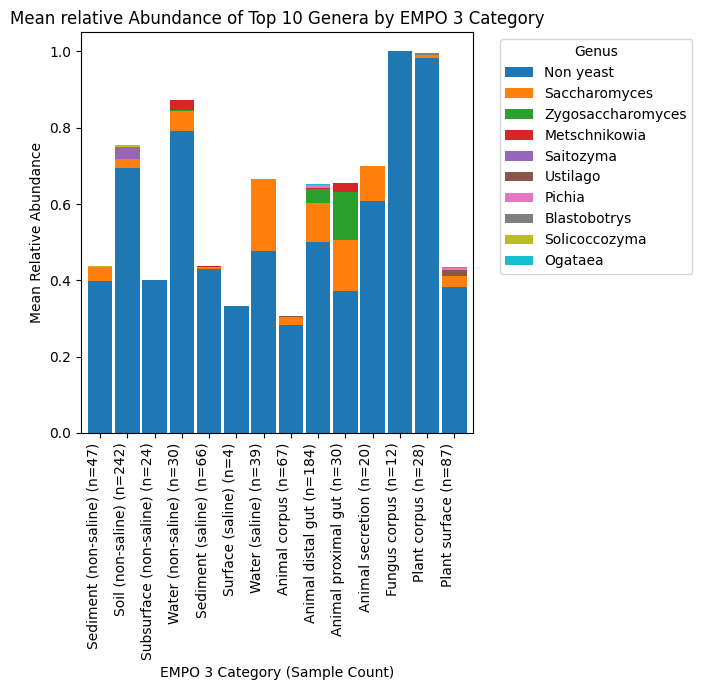

In [ ]:


# Calculate the number of samples per empo_3 category
# Ensure sample counts are aligned with the sorted empo_3 categories for the plot
sample_counts_by_empo3 = df_meta['empo_3'].value_counts()
sample_counts_by_empo3

# Create new labels including sample counts, ensuring the order matches the sorted plot_data_absolute_grouped index
new_x_labels = [f'{category} (n={sample_counts_by_empo3.get(category, 0)})' for category in plot_data_MeanRelative_grouped.index]


# Plotting
ax = plot_data_MeanRelative_grouped.plot(kind='bar', stacked=True, figsize=(7, 7),
    width=0.9 # Adjust bar width as needed
    )
ax.set_xlabel("EMPO 3 Category (Sample Count)")
ax.set_ylabel("Mean Relative Abundance")
ax.set_title("Mean relative Abundance of Top 10 Genera by EMPO 3 Category")
ax.legend(title="Genus", bbox_to_anchor=(1.05, 1), loc='upper left')

# Set the new x-axis labels
ax.set_xticklabels(new_x_labels, rotation=90, ha='right')

plt.tight_layout()
plt.show()

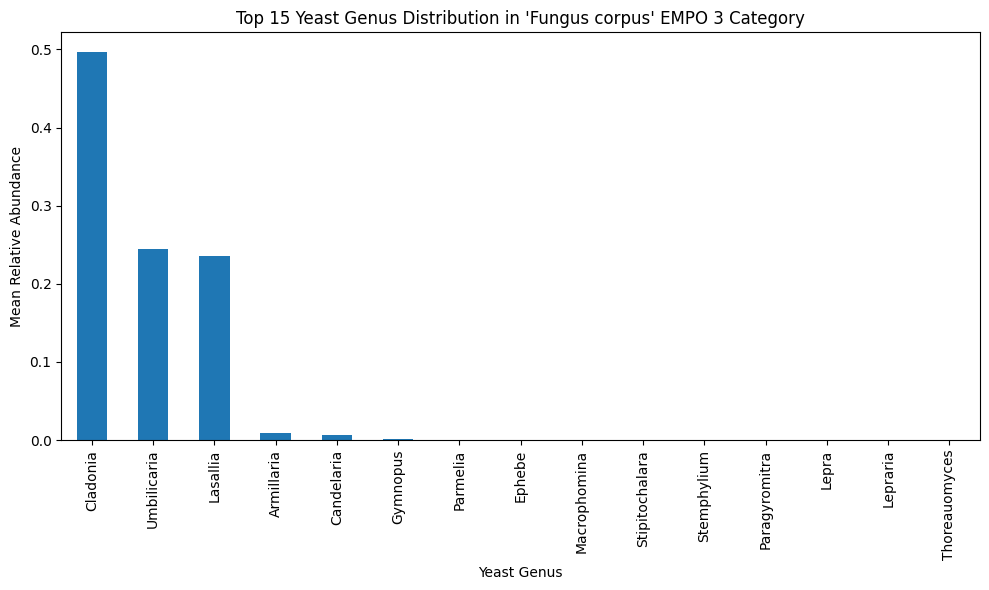

In [ ]:
# Ensure mean_relative_abundance_by_empo3_yeast is available from previous cells

# Select the column for 'Fungus corpus'
fungus_corpus_distribution = mean_relative_abundance_by_empo3_yeast['Fungus corpus']

# Sort the genera by mean relative abundance in descending order within Fungus corpus
sorted_fungus_corpus_distribution = fungus_corpus_distribution.sort_values(ascending=False)

# Display the distribution (optional, keep for context)
# print("Yeast Genus Distribution in 'Fungus corpus' EMPO 3 Category (Mean Relative Abundance):")
# display(sorted_fungus_corpus_distribution)

# Plot the distribution of the top genera (e.g., top 10 or 20)
top_n = 15 # Define how many top genera to plot
plot_data_fungus_corpus = sorted_fungus_corpus_distribution.nlargest(top_n)

ax = plot_data_fungus_corpus.plot(kind='bar', figsize=(10, 6))

ax.set_xlabel("Yeast Genus")
ax.set_ylabel("Mean Relative Abundance")
ax.set_title(f"Top {top_n} Yeast Genus Distribution in 'Fungus corpus' EMPO 3 Category")
plt.tight_layout()
plt.show()

Cladonia relative abundance per sample in 'Fungus corpus' EMPO 3 category:


,Cladonia
13114.uren.82.s008,0.887228
13114.uren.82.s007,0.875108
13114.uren.82.s009,0.857423
13114.uren.82.s006,0.757317
13114.uren.82.s005,0.555581
13114.uren.82.s003,0.547402
13114.uren.82.s001,0.522731
13114.uren.82.s002,0.511017
13114.uren.82.s004,0.450708
13114.uren.82.s012,0.000611


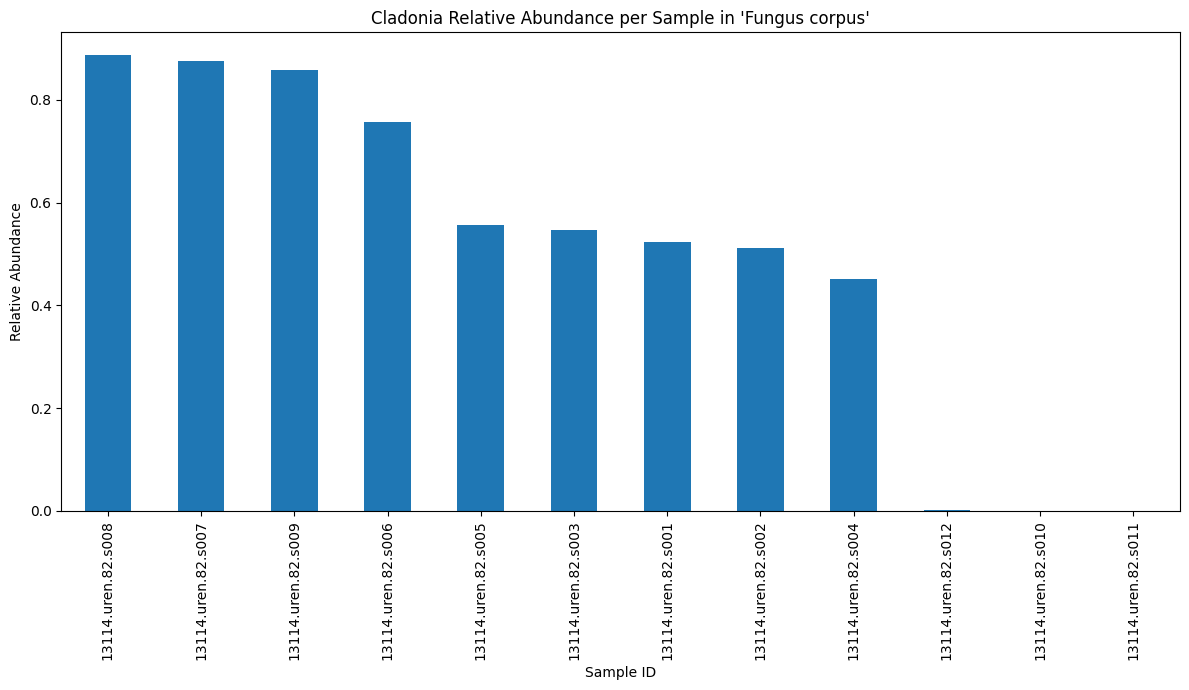

In [ ]:
# Ensure df_meta and yeast_genus_relative_abundance_df are available from previous cells

# Get the sample IDs for 'Fungus corpus' EMPO 3 category
fungus_corpus_sample_names = df_meta[df_meta['empo_3'] == 'Fungus corpus'].index

# Filter yeast_genus_relative_abundance_df to include only these samples
fungus_corpus_relative_abundance_df = yeast_genus_relative_abundance_df[fungus_corpus_sample_names]

# Check if 'Cladonia' is present in the index (genera) of the filtered DataFrame
if 'Cladonia' in fungus_corpus_relative_abundance_df.index:
    # Select the relative abundance values for 'Cladonia' for these samples
    cladonia_relative_abundance_in_fungus_corpus = fungus_corpus_relative_abundance_df.loc['Cladonia']

    # Sort the relative abundances for better visualization
    cladonia_relative_abundance_in_fungus_corpus_sorted = cladonia_relative_abundance_in_fungus_corpus.sort_values(ascending=False)

    # Display the relative abundance values
    print("Cladonia relative abundance per sample in 'Fungus corpus' EMPO 3 category:")
    display(cladonia_relative_abundance_in_fungus_corpus_sorted)

    # Plot the distribution of Cladonia relative abundance per sample
    ax = cladonia_relative_abundance_in_fungus_corpus_sorted.plot(kind='bar', figsize=(12, 7))
    ax.set_xlabel("Sample ID")
    ax.set_ylabel("Relative Abundance")
    ax.set_title("Cladonia Relative Abundance per Sample in 'Fungus corpus'")
    plt.tight_layout()
    plt.show()

else:
    print("'Cladonia' genus not found in the yeast_genus_relative_abundance_df DataFrame.")

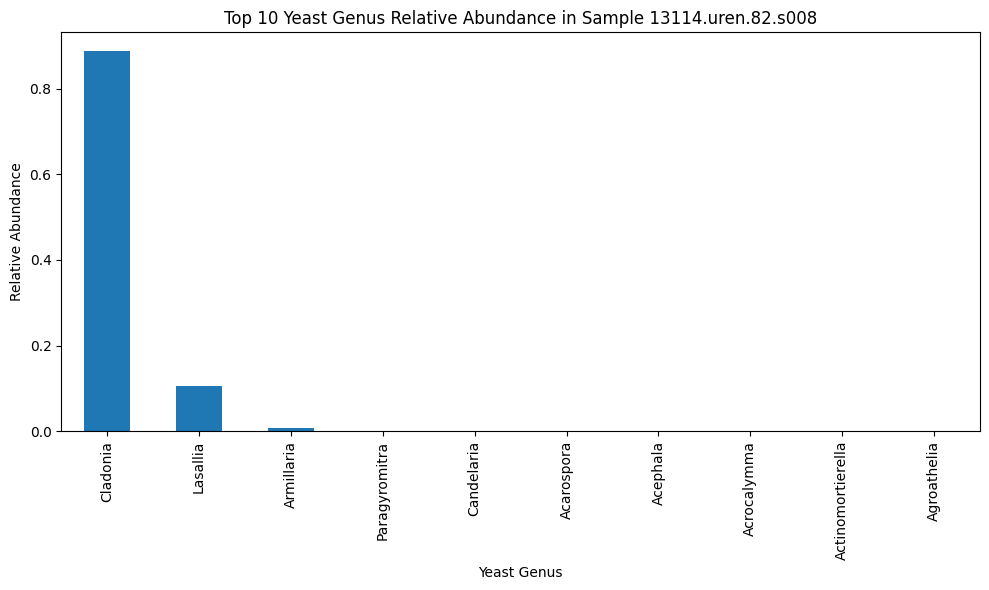

In [ ]:
# Ensure yeast_genus_relative_abundance_df is available from previous cells

# Select the relative abundance data for the specific sample
sample_relative_abundance = yeast_genus_relative_abundance_df['13114.uren.82.s008']

# Get the top 10 most abundant genera in this sample
top10_genera_in_sample = sample_relative_abundance.nlargest(10).index

# Filter the relative abundance Series to include only the top 10 genera
top10_sample_relative_abundance = sample_relative_abundance.loc[top10_genera_in_sample]

# Plotting a bar chart of the top 10 relative abundances
ax = top10_sample_relative_abundance.plot(kind='bar', figsize=(10, 6))

ax.set_xlabel("Yeast Genus")
ax.set_ylabel("Relative Abundance")
ax.set_title(f"Top 10 Yeast Genus Relative Abundance in Sample 13114.uren.82.s008")
plt.tight_layout()
plt.show()